In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)import os



In [51]:
df = pd.read_csv('/Users/rishidwivedi/Downloads/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [52]:
df = df.iloc[:,1:] #id wala column hata diya

In [53]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [54]:
from sklearn.preprocessing import LabelEncoder


In [55]:
encoder = LabelEncoder()


In [57]:
df['Species'] = encoder.fit_transform(df['Species'])


In [58]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [62]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]


In [63]:
df.head()


,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

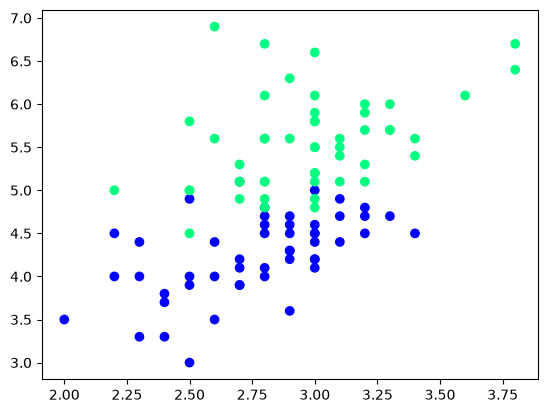

In [65]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')


In [77]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
55,2.8,4.5,1
96,2.9,4.2,1
101,2.7,5.1,2
75,3.0,4.4,1
104,3.0,5.8,2
67,2.7,4.1,1
53,2.3,4.0,1
66,3.0,4.5,1
56,3.3,4.7,1
88,3.0,4.1,1


In [78]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [79]:
df_train

,SepalWidthCm,PetalLengthCm,Species
93,2.3,3.3,1
69,2.5,3.9,1
114,2.8,5.1,2
143,3.2,5.9,2
70,3.2,4.8,1
138,3.0,4.8,2
130,2.8,6.1,2
116,3.0,5.5,2
76,2.8,4.8,1
59,2.7,3.9,1


In [80]:
df_val

,SepalWidthCm,PetalLengthCm,Species
108,2.5,5.8,2
79,2.6,3.5,1
50,3.2,4.7,1
71,2.8,4.0,1
110,3.2,5.1,2


In [81]:
df_test

,SepalWidthCm,PetalLengthCm,Species
80,2.4,3.8,1
113,2.5,5.0,2
126,2.8,4.8,2
81,2.4,3.7,1
87,2.3,4.4,1


In [82]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [83]:
y_test

array([2, 1, 1, 1, 2])

Case 1 - Bagging

In [ ]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True) #replace=true mtlb ek row multiple times aa skta h

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
59,2.7,3.9,1
114,2.8,5.1,2
130,2.8,6.1,2
69,2.5,3.9,1
93,2.3,3.3,1
59,2.7,3.9,1
76,2.8,4.8,1
69,2.5,3.9,1


In [85]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [86]:
dt_bag1 = DecisionTreeClassifier()

In [87]:
evaluate(dt_bag1,X,y)

Model Accuracy: 1.0000


1.0

In [88]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
70,3.2,4.8,1
143,3.2,5.9,2
116,3.0,5.5,2
143,3.2,5.9,2
116,3.0,5.5,2
70,3.2,4.8,1
70,3.2,4.8,1
143,3.2,5.9,2


In [89]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

Model Accuracy: 1.0000


1.0

In [90]:

# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
93,2.3,3.3,1
69,2.5,3.9,1
130,2.8,6.1,2
114,2.8,5.1,2
76,2.8,4.8,1
59,2.7,3.9,1
59,2.7,3.9,1
138,3.0,4.8,2


In [ ]:

#dt_bag3 = DecisionTreeClassifier()
#evaluate(dt_bag3,X,y)

NameError: name 'dt_bag3' is not defined

In [93]:
#predict

dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y

_IncompleteInputError: incomplete input (3951002885.py, line 4)

RANDOM SUBSPACES

In [95]:
df1 = pd.read_csv('/Users/rishidwivedi/Downloads/Iris.csv')
df1 = df1.sample(10)

In [96]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
80,81,5.5,2.4,3.8,1.1,Iris-versicolor
9,10,4.9,3.1,1.5,0.1,Iris-setosa
114,115,5.8,2.8,5.1,2.4,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
79,80,5.7,2.6,3.5,1.0,Iris-versicolor
33,34,5.5,4.2,1.4,0.2,Iris-setosa
41,42,4.5,2.3,1.3,0.3,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
121,122,5.6,2.8,4.9,2.0,Iris-virginica
100,101,6.3,3.3,6.0,2.5,Iris-virginica


In [97]:
df1.sample(2,replace=True,axis=1)


,SepalWidthCm,SepalLengthCm
80,2.4,5.5
9,3.1,4.9
114,2.8,5.8
146,2.5,6.3
79,2.6,5.7
33,4.2,5.5
41,2.3,4.5
6,3.4,4.6
121,2.8,5.6
100,3.3,6.3


RANDOM PATCHES

In [98]:
df1


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
80,81,5.5,2.4,3.8,1.1,Iris-versicolor
9,10,4.9,3.1,1.5,0.1,Iris-setosa
114,115,5.8,2.8,5.1,2.4,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
79,80,5.7,2.6,3.5,1.0,Iris-versicolor
33,34,5.5,4.2,1.4,0.2,Iris-setosa
41,42,4.5,2.3,1.3,0.3,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
121,122,5.6,2.8,4.9,2.0,Iris-virginica
100,101,6.3,3.3,6.0,2.5,Iris-virginica
